# Perineuronal-net (PNN) percentages by brain area

Source data: `CellCounting_clean_avg.csv`. The `*_avg_percent_double` columns are
the **percentage of neurons that co-localise with a PNN** in each brain area
(PFC = prefrontal cortex, HPC = hippocampus).

This notebook plots, for each brain area:
1. % with PNN by **Age x Sex** (Age on x, Sex as colour) — image style.
2. % with PNN by **Sex x Age** (Sex on x, Age as colour) — image style.
3. % with PNN vs % without PNN (stacked bar) — explicit "with vs without" view.

Bars = mean, error bars = SEM, dots = individual mice.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_context("notebook")
sns.set_style("whitegrid")

REPO = Path.cwd().parent
df = pd.read_csv(REPO / "CellCounting_clean_avg.csv")

AGE_ORDER = ["Old", "Mid", "Young"]
SEX_ORDER = ["Female", "Male"]
SEX_PALETTE = {"Female": "#e07a9c", "Male": "#1f6f9b"}            # pink, blue
AGE_PALETTE = {"Old": "#6aaa64", "Mid": "#f4d35e", "Young": "#ee964b"}  # green, yellow, orange

AREAS = [
    ("PFC_avg_percent_double", "PFC"),
    ("HPC_avg_percent_double", "HPC"),
]

print(f"n = {len(df)}")
print("\nGroup sizes:")
print(df.groupby(['Sex_new','Age_new']).size().to_string())
df.head()


n = 47

Group sizes:
Sex_new  Age_new
Female   Mid        13
         Old         9
         Young       5
Male     Mid         9
         Old         7
         Young       4


,ID,Age_new,Sex_new,Light_new,total_percent_double,PFC_avg_double,PFC_avg_percent_double,HPC_avg_double,HPC_avg_percent_double
0,1,Old,Male,CTR,6.092437,3,1.818182,26.0,8.306709
1,7,Old,Male,ISF,14.369501,15,6.666667,34.0,29.310345
2,28,Old,Male,ISF,19.037657,39,10.955056,52.0,42.622951
3,31,Old,Male,CTR,9.848485,12,6.250000,14.0,20.000000
4,33,Old,Male,CTR,9.230769,19,4.578313,29.0,27.619048


## 1. % with PNN — bar charts by Age x Sex and Sex x Age

2x2 grid: rows = brain area (PFC, HPC); columns = (Age on x, Sex hue) | (Sex on x, Age hue).


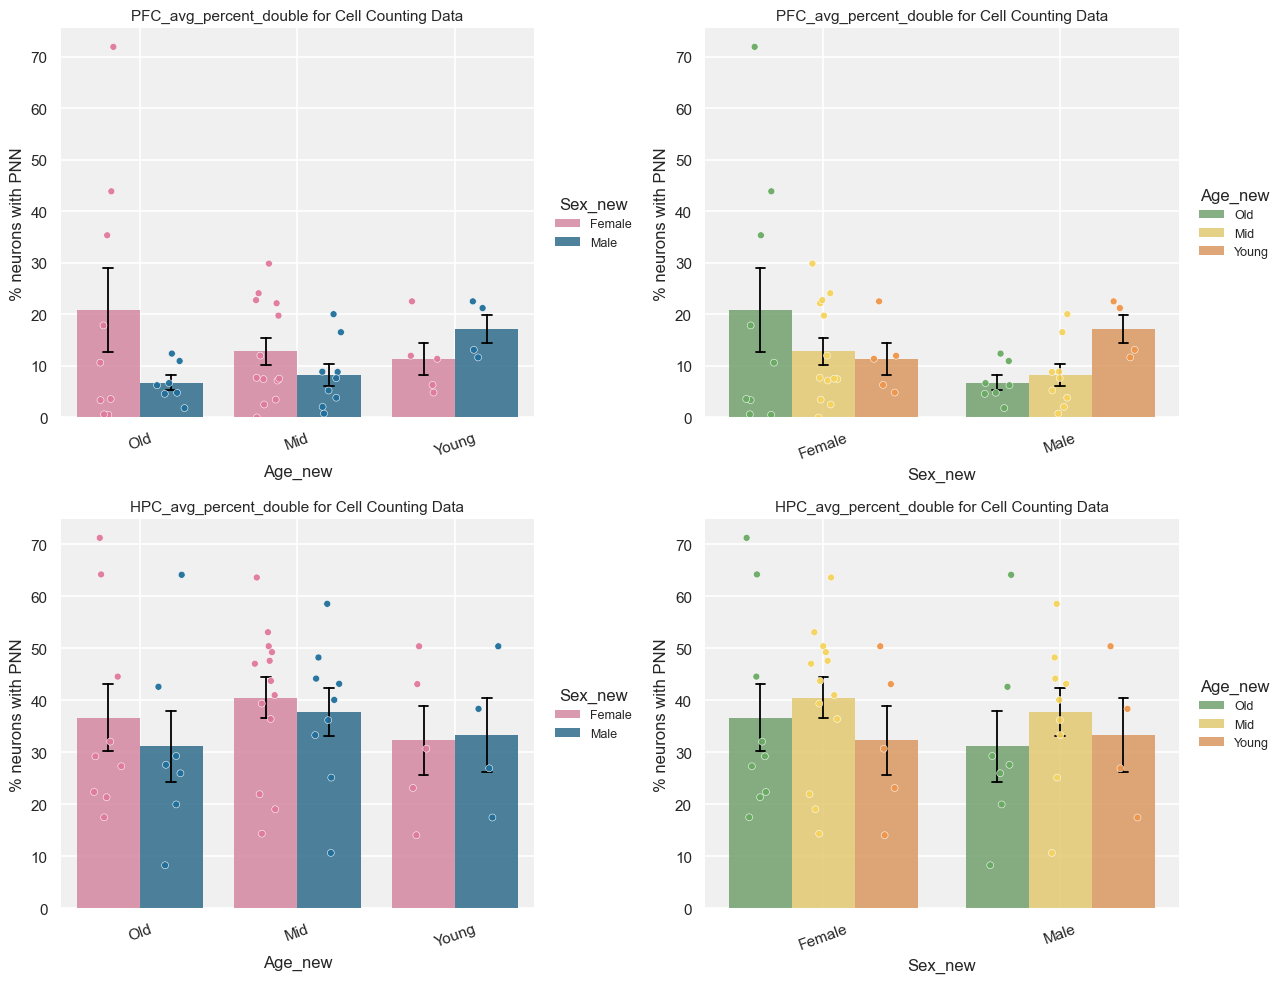


Mean % with PNN per cell:

--- PFC ---
                  mean   sem  count
Sex_new Age_new                    
Female  Mid      12.80  2.69     13
        Old      20.86  8.24      9
        Young    11.40  3.11      5
Male    Mid       8.19  2.15      9
        Old       6.78  1.40      7
        Young    17.13  2.77      4

--- HPC ---
                  mean   sem  count
Sex_new Age_new                    
Female  Mid      40.55  3.99     13
        Old      36.67  6.44      9
        Young    32.30  6.57      5
Male    Mid      37.74  4.62      9
        Old      31.14  6.74      7
        Young    33.31  7.12      4


In [2]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for r, (col, area) in enumerate(AREAS):
    # --- Left: Age on x, Sex as hue ---
    ax = axes[r, 0]
    sns.barplot(
        data=df, x="Age_new", y=col, hue="Sex_new",
        order=AGE_ORDER, hue_order=SEX_ORDER, palette=SEX_PALETTE,
        errorbar="se", capsize=0.12, err_kws={"linewidth": 1.3, "color": "black"},
        edgecolor="none", alpha=0.85, ax=ax,
    )
    sns.stripplot(
        data=df, x="Age_new", y=col, hue="Sex_new",
        order=AGE_ORDER, hue_order=SEX_ORDER, palette=SEX_PALETTE,
        dodge=True, jitter=0.18, size=5, alpha=0.95,
        edgecolor="white", linewidth=0.4, ax=ax, legend=False,
    )
    ax.set_title(f"{area}_avg_percent_double for Cell Counting Data", fontsize=11)
    ax.set_xlabel("Age_new"); ax.set_ylabel("% neurons with PNN")
    ax.tick_params(axis="x", labelrotation=20)
    ax.set_facecolor("#f0f0f0")
    for s in ax.spines.values(): s.set_visible(False)
    ax.grid(True, color="white", linewidth=1.2)
    h, l = ax.get_legend_handles_labels()
    ax.legend(h[:2], l[:2], title="Sex_new", loc="center left",
              bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=9)

    # --- Right: Sex on x, Age as hue ---
    ax = axes[r, 1]
    sns.barplot(
        data=df, x="Sex_new", y=col, hue="Age_new",
        order=SEX_ORDER, hue_order=AGE_ORDER, palette=AGE_PALETTE,
        errorbar="se", capsize=0.12, err_kws={"linewidth": 1.3, "color": "black"},
        edgecolor="none", alpha=0.85, ax=ax,
    )
    sns.stripplot(
        data=df, x="Sex_new", y=col, hue="Age_new",
        order=SEX_ORDER, hue_order=AGE_ORDER, palette=AGE_PALETTE,
        dodge=True, jitter=0.18, size=5, alpha=0.95,
        edgecolor="white", linewidth=0.4, ax=ax, legend=False,
    )
    ax.set_title(f"{area}_avg_percent_double for Cell Counting Data", fontsize=11)
    ax.set_xlabel("Sex_new"); ax.set_ylabel("% neurons with PNN")
    ax.tick_params(axis="x", labelrotation=20)
    ax.set_facecolor("#f0f0f0")
    for s in ax.spines.values(): s.set_visible(False)
    ax.grid(True, color="white", linewidth=1.2)
    h, l = ax.get_legend_handles_labels()
    ax.legend(h[:3], l[:3], title="Age_new", loc="center left",
              bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

print("\nMean % with PNN per cell:")
for col, area in AREAS:
    print(f"\n--- {area} ---")
    print(df.groupby(['Sex_new','Age_new'])[col]
          .agg(['mean','sem','count']).round(2).to_string())


## 2. % with vs without PNN — stacked view per brain area

Same data, complement view: for each `Sex x Age` cell we show the mean **% with
PNN** stacked on top of the implied **% without PNN** (100 - mean). Useful for
the at-a-glance comparison; the bar plots above are the better statistical view.


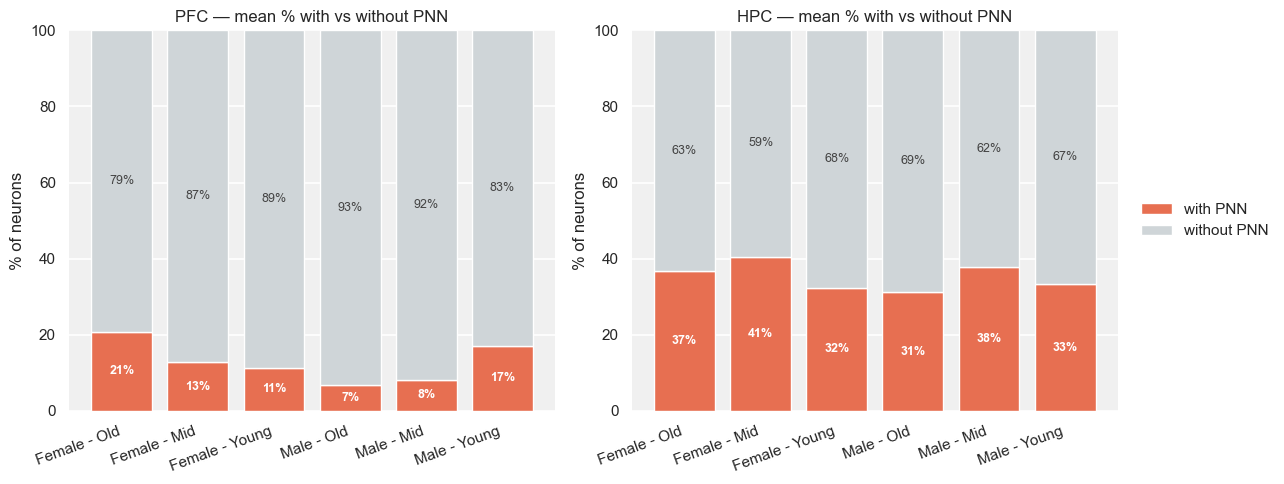

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
WITH_COLOUR    = "#e76f51"  # coral
WITHOUT_COLOUR = "#cfd5d8"  # light grey

for ax, (col, area) in zip(axes, AREAS):
    means = (df.groupby(['Sex_new','Age_new'])[col].mean()
               .reindex(pd.MultiIndex.from_product([SEX_ORDER, AGE_ORDER],
                                                   names=['Sex_new','Age_new']))
               .reset_index())
    means["with"] = means[col]
    means["without"] = 100 - means["with"]
    means["label"] = means["Sex_new"] + " - " + means["Age_new"]

    x = np.arange(len(means))
    ax.bar(x, means["with"], color=WITH_COLOUR, label="with PNN", edgecolor="white")
    ax.bar(x, means["without"], bottom=means["with"], color=WITHOUT_COLOUR,
           label="without PNN", edgecolor="white")
    for xi, w in zip(x, means["with"]):
        if pd.notna(w):
            ax.text(xi, w/2, f"{w:.0f}%", ha="center", va="center",
                    fontsize=9, color="white", fontweight="bold")
            ax.text(xi, w + (100-w)/2, f"{100-w:.0f}%", ha="center", va="center",
                    fontsize=9, color="#444")

    ax.set_xticks(x); ax.set_xticklabels(means["label"], rotation=20, ha="right")
    ax.set_ylim(0, 100)
    ax.set_title(f"{area} — mean % with vs without PNN", fontsize=12)
    ax.set_ylabel("% of neurons")
    ax.set_facecolor("#f0f0f0")
    for s in ax.spines.values(): s.set_visible(False)
    ax.grid(True, color="white", linewidth=1.2, axis="y")

axes[-1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.tight_layout(); plt.show()


## 3. Two-way ANOVA on each brain area (Age x Sex)

Sanity check on whether the visual differences are statistically supported.
Type III sums of squares (unbalanced cells), with interaction term.


In [4]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

for col, area in AREAS:
    print(f"\n=== {area} ({col}) ===")
    mod = smf.ols(f"{col} ~ C(Age_new) * C(Sex_new)", data=df).fit()
    anova = sm.stats.anova_lm(mod, typ=3)
    print(anova.round(4).to_string())



=== PFC (PFC_avg_percent_double) ===
                          sum_sq    df        F  PR(>F)
Intercept              2131.2552   1.0  13.0111  0.0008
C(Age_new)              434.6372   2.0   1.3267  0.2765
C(Sex_new)              112.9841   1.0   0.6898  0.4111
C(Age_new):C(Sex_new)   572.7091   2.0   1.7482  0.1868
Residual               6715.9007  41.0      NaN     NaN

=== HPC (HPC_avg_percent_double) ===
                           sum_sq    df        F  PR(>F)
Intercept              21374.5103   1.0  84.4404  0.0000
C(Age_new)               260.5716   2.0   0.5147  0.6015
C(Sex_new)                41.8217   1.0   0.1652  0.6865
C(Age_new):C(Sex_new)     60.9006   2.0   0.1203  0.8870
Residual               10378.3839  41.0      NaN     NaN


## 4. Coping with small n and outliers — planned contrasts, transforms, BFs

The omnibus ANOVA spreads alpha across three effects (Age, Sex, Age*Sex) and is
hurt by the small unbalanced cells. The visual signal that matters is **Old
Female PFC vs Old Male PFC** (n=9 vs 7, mean 20.9% vs 6.8%). Here we run a
*pre-specified* contrast and check whether the result is stable under:

1. **Outlier exclusion** — drop points outside Tukey's 1.5*IQR fence per cell.
2. **`log(1+x)` transform** — compress the heavy-tailed Female distribution.
3. **Yuen's trimmed-means t-test** — robust analogue of Welch t (20% trim).
4. **Bayes factor (JZS prior)** — quantifies evidence for null vs alternative
   so we distinguish "underpowered" from "actually no effect".

If the planned contrast is robust across all four, the effect is real and we
just need more animals. If it disappears under outlier-robust tests, the
visual was being driven by a few extreme animals and more n would not help.


In [5]:
def welch_t(a, b):
    t, p = stats.ttest_ind(a, b, equal_var=False)
    sp = np.sqrt(((len(a)-1)*a.var(ddof=1) + (len(b)-1)*b.var(ddof=1)) /
                 (len(a)+len(b)-2))
    d  = (a.mean() - b.mean()) / sp if sp > 0 else np.nan
    J  = 1 - (3/(4*(len(a)+len(b))-9))
    return t, p, J*d  # Hedges g

def boxplot_outliers_mask(x):
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    return (x >= lo) & (x <= hi)

def yuen_t(a, b, trim=0.2):
    def _winsorize(x, trim):
        n = len(x); g = int(np.floor(trim * n))
        s = np.sort(x).copy()
        if g > 0:
            s[:g] = s[g]; s[-g:] = s[-g-1]
        return s
    def _trimmed_stats(x, trim):
        n = len(x); g = int(np.floor(trim * n)); h = n - 2*g
        tm = stats.trim_mean(x, trim)
        w  = _winsorize(x, trim)
        sw2 = w.var(ddof=1)
        se2 = (n - 1) * sw2 / (h * (h - 1)) if h > 1 else np.nan
        return tm, se2, h
    tm_a, se2_a, h_a = _trimmed_stats(a, trim)
    tm_b, se2_b, h_b = _trimmed_stats(b, trim)
    if not (np.isfinite(se2_a) and np.isfinite(se2_b)) or (se2_a + se2_b) <= 0:
        return np.nan, np.nan, np.nan
    t = (tm_a - tm_b) / np.sqrt(se2_a + se2_b)
    df_num = (se2_a + se2_b) ** 2
    df_den = se2_a**2 / (h_a - 1) + se2_b**2 / (h_b - 1)
    df = df_num / df_den if df_den > 0 else np.nan
    p = 2 * stats.t.sf(abs(t), df) if np.isfinite(df) else np.nan
    return t, df, p

def bf10_jzs_from_t(t, n1, n2, r=np.sqrt(2)/2):
    from scipy.integrate import quad
    df = n1 + n2 - 2
    n_eff = (n1 * n2) / (n1 + n2)
    def integrand(g):
        return ((1 + n_eff*g*r*r) ** -0.5) * \
               ((1 + (t*t)/((1 + n_eff*g*r*r) * df)) ** (-(df+1)/2)) * \
               (g ** -1.5) * np.exp(-1/(2*g)) / np.sqrt(2*np.pi)
    num, _ = quad(integrand, 0, np.inf, limit=200)
    denom = (1 + (t*t)/df) ** (-(df+1)/2)
    return num / denom

CONTRASTS = [
    ("PFC", "PFC_avg_percent_double", "Old"),
    ("HPC", "HPC_avg_percent_double", "Old"),
]

print(f"{'Area':<5}{'test':<28}{'n_F':>4}{'n_M':>4}{'stat':>9}{'p':>9}{'g/d':>7}")
print("-" * 70)
for area, col, age in CONTRASTS:
    a = df[(df.Age_new==age) & (df.Sex_new=='Female')][col].values
    b = df[(df.Age_new==age) & (df.Sex_new=='Male')][col].values

    t, p, g = welch_t(a, b)
    print(f"{area:<5}{'Welch t (raw)':<28}{len(a):>4}{len(b):>4}{t:>9.2f}{p:>9.4f}{g:>7.2f}")

    a2, b2 = a[boxplot_outliers_mask(a)], b[boxplot_outliers_mask(b)]
    t2, p2, g2 = welch_t(a2, b2)
    print(f"{area:<5}{'Welch t (no IQR outliers)':<28}{len(a2):>4}{len(b2):>4}"
          f"{t2:>9.2f}{p2:>9.4f}{g2:>7.2f}")

    la, lb = np.log1p(a), np.log1p(b)
    t3, p3, g3 = welch_t(la, lb)
    print(f"{area:<5}{'Welch t on log1p(x)':<28}{len(a):>4}{len(b):>4}"
          f"{t3:>9.2f}{p3:>9.4f}{g3:>7.2f}")

    ty, dfy, py = yuen_t(a, b, trim=0.2)
    print(f"{area:<5}{'Yuen t (20% trim)':<28}{len(a):>4}{len(b):>4}"
          f"{ty:>9.2f}{py:>9.4f}{'-':>7}")

    U, pmw = stats.mannwhitneyu(a, b, alternative='two-sided')
    print(f"{area:<5}{'Mann-Whitney U':<28}{len(a):>4}{len(b):>4}{U:>9.0f}{pmw:>9.4f}{'-':>7}")

    bf10 = bf10_jzs_from_t(t, len(a), len(b))
    bf01 = 1.0 / bf10
    interp = ('strong evidence for null'     if bf01 >= 10 else
              'moderate evidence for null'   if bf01 >= 3  else
              'anecdotal/inconclusive'       if 1/3 < bf10 < 3 else
              'moderate evidence for effect' if bf10 >= 3 else 'strong evidence for effect')
    print(f"{area:<5}{'BF10 (JZS, r=sqrt(2)/2)':<28}{len(a):>4}{len(b):>4}"
          f"{bf10:>9.2f}{'':>9}{'-':>7}")
    print(f"      -> BF01 = {bf01:.2f}    ({interp})")
    print()


Area test                         n_F n_M     stat        p    g/d
----------------------------------------------------------------------
PFC  Welch t (raw)                  9   7     1.68   0.1286   0.71
PFC  Welch t (no IQR outliers)      9   7     1.68   0.1286   0.71
PFC  Welch t on log1p(x)            9   7     0.75   0.4725   0.32
PFC  Yuen t (20% trim)              9   7     1.20   0.2732      -
PFC  Mann-Whitney U                 9   7       35   0.7577      -
PFC  BF10 (JZS, r=sqrt(2)/2)        9   7     1.06               -
      -> BF01 = 0.94    (anecdotal/inconclusive)

HPC  Welch t (raw)                  9   7     0.59   0.5632   0.28
HPC  Welch t (no IQR outliers)      9   6     1.39   0.1874   0.62
HPC  Welch t on log1p(x)            9   7     0.70   0.4959   0.35
HPC  Yuen t (20% trim)              9   7     0.58   0.5736      -
HPC  Mann-Whitney U                 9   7       37   0.6065      -
HPC  BF10 (JZS, r=sqrt(2)/2)        9   7     0.48               -
      ->

### Interpretation cheat-sheet

- **PFC Old-F vs Old-M.** If raw Welch t is borderline (p ~ 0.13, g ~ 0.7)
  *and* the IQR-excluded / log / Yuen tests stay borderline, the effect is real
  and we are underpowered. If they collapse, the raw t was an outlier artifact
  and more n probably will not help.
- **HPC Old-F vs Old-M.** Expect everything to come back null. The BF should
  give moderate-to-strong evidence *for* the null — that is the right way to
  say "the data positively support no effect" instead of "we failed to reject".

To add contrasts (Mid-F vs Mid-M, Old-F vs Young-F, etc.), edit `CONTRASTS`
above. With 6 cells there are 15 pairwise comparisons — pre-specify the 1-3
you actually care about to avoid multiple-comparison creep.
